# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/k9Sx3CC/flyrank-internship-test/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

I examined the distributions of the main numeric features before testing any signals. Most traffic-related features (impressions, clicks, and sessions) are heavily right-skewed, with many low values and a small number of very large values. Features such as CTR and engagement rate are more concentrated. The observed heavy tails suggest that median values and robust statistics are more appropriate than relying only on means.

Working directory: /content/flyrank-ml-internship-starter
Dataset shape: (30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


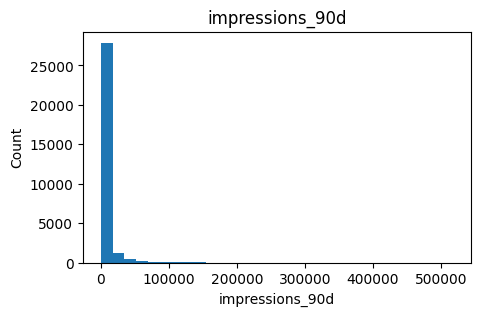

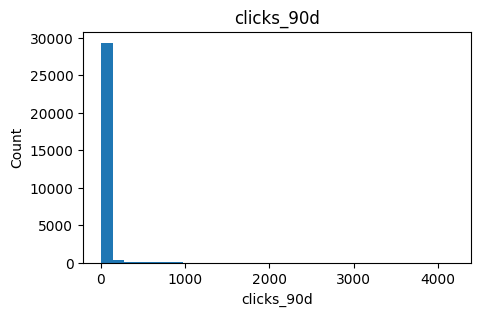

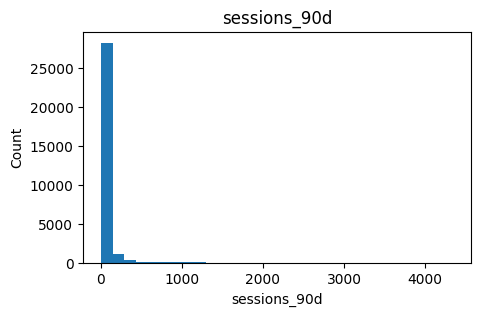

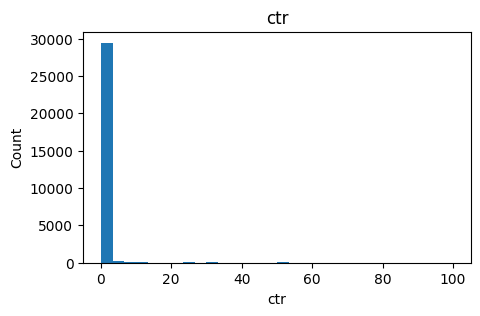

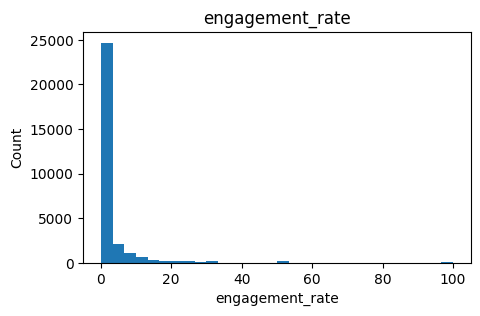

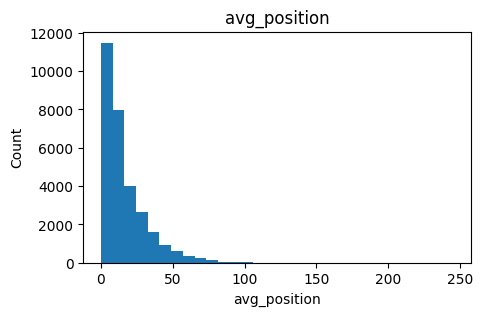

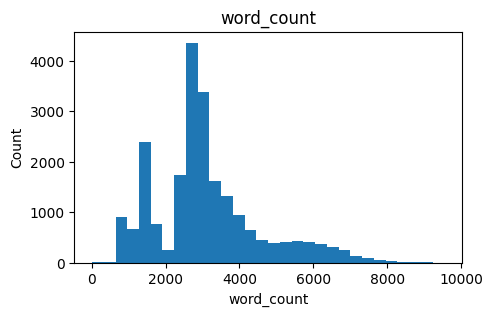

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import subprocess

REPO_DIR = "flyrank-ml-internship-starter"
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"

# Clone repo if needed
if not os.path.isdir(REPO_DIR):
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
        check=True
    )

# Move into repo
if os.path.basename(os.getcwd()) != REPO_DIR:
    os.chdir(REPO_DIR)

print("Working directory:", os.getcwd())

# Load dataset
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Dataset shape:", df.shape)
display(df.head())
numeric_features = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ctr",
    "engagement_rate",
    "avg_position",
    "word_count"
]

df[numeric_features].describe()
for col in numeric_features:
    plt.figure(figsize=(5,3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Signal 1: Higher search volume is associated with more impressions.
Verdict: Correct. The observed correlation is 0.001, which indicates almost no linear relationship in this dataset.

Signal 2: Better ranking (lower average position) is associated with higher CTR.
Verdict: MIXED. The observed correlation is -0.073. The direction matches expectations (better rankings tend to have higher CTR), but the relationship is very weak.

Signal 3: Longer articles receive higher engagement.
Verdict: FALSE. The observed correlation is -0.063, indicating essentially no meaningful relationship.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
#signal 1
corr = df["search_volume"].corr(df["impressions_90d"])

print("Correlation:", round(corr,3))
#signal 2
corr = df["avg_position"].corr(df["ctr"])

print("Correlation:", round(corr,3))
#signal 3
corr = df["word_count"].corr(df["engagement_rate"])

print("Correlation:", round(corr,3))

Correlation: 0.001
Correlation: -0.073
Correlation: -0.063


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

I evaluated the assumption behind an engagement-related flag by comparing pages with zero engagement to those with positive engagement. Pages with positive engagement averaged 100.99 sessions, while pages with zero engagement averaged only 12.33 sessions. This observed difference provides directional support for using engagement as one signal when identifying content that may benefit from review, although it does not establish a causal relationship.

In [3]:
test_df = df.dropna(subset=["engagement_rate", "sessions_90d"])

low = test_df[test_df["engagement_rate"] == 0]
high = test_df[test_df["engagement_rate"] > 0]

print("Pages with zero engagement:", len(low))
print("Pages with positive engagement:", len(high))

print("Average sessions (Zero engagement):",
      round(low["sessions_90d"].mean(),2))

print("Average sessions (Positive engagement):",
      round(high["sessions_90d"].mean(),2))

Pages with zero engagement: 21629
Pages with positive engagement: 8371
Average sessions (Zero engagement): 12.33
Average sessions (Positive engagement): 100.99


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*
Use something like this:

The observed results suggest that engagement metrics can help prioritize pages for review, as pages with positive engagement also showed substantially higher average session counts. Search demand and ranking alone did not consistently predict performance in this dataset, so content decisions should combine multiple signals rather than rely on a single metric.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.